In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import sklearn
sklearn.set_config(display='text')
from sklearn import datasets
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Activation

회귀 신경망을 이용해 캘리포니아 집값을 예측하는 모델을 만들어 본다.

회귀 신경망에 사용할 데이터 준비

In [2]:
# 데이터 불러오기
raw_data = pd.read_csv('./data/boston.csv') # 보스턴 집값 데이터를 읽어온다.

# 피처, 레이블 저장
xData = raw_data.drop('medv', axis=1)
yData = raw_data['medv']

print(xData.shape, yData.shape)
# 총 8개의 피쳐가 있고, 이는 신경망을 생성할 때 사용된다.

# 레이블 종류 확인
# 레이블의 종류를 확인함으로써 분류 문제인지 아니면 회귀 문제인지 파악할 수 잇고, 분류 문제라면 몇 가지 클래스로 구분되는 지 알 수 있다.
print(len(set(yData)))
print(set(yData))

# 회귀 문제일 경우 원-핫 인코딩은 사용하지 않는다.
# 학습 데이터와 테스트 데이터로 분할
x_train, x_test, y_train, y_test = train_test_split(xData, yData, random_state=0)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(506, 13) (506,)
229
{5.0, 6.3, 7.2, 8.8, 7.4, 10.2, 11.8, 12.7, 13.6, 14.5, 15.0, 16.5, 17.5, 18.9, 18.2, 20.4, 21.6, 22.9, 21.7, 24.0, 19.9, 26.6, 26.5, 27.5, 23.1, 27.1, 28.7, 24.7, 30.8, 33.4, 34.7, 34.9, 36.2, 35.4, 31.6, 33.0, 38.7, 33.2, 43.8, 41.3, 37.2, 39.8, 42.3, 48.5, 44.8, 50.0, 46.7, 48.3, 44.0, 48.8, 46.0, 10.5, 11.5, 11.0, 12.5, 12.0, 13.5, 13.0, 14.0, 16.6, 16.0, 16.1, 16.4, 17.4, 17.1, 17.0, 17.6, 17.9, 18.4, 18.6, 18.5, 18.0, 18.1, 19.6, 19.4, 19.5, 19.1, 19.0, 20.0, 20.5, 20.9, 20.6, 20.1, 21.0, 21.4, 21.5, 21.9, 21.1, 22.0, 22.5, 22.6, 22.4, 22.1, 23.4, 23.5, 23.9, 23.6, 23.0, 24.1, 24.6, 24.4, 24.5, 25.0, 25.1, 26.4, 27.0, 27.9, 28.0, 28.4, 28.1, 28.5, 28.6, 29.4, 29.9, 29.6, 29.1, 29.0, 30.5, 30.1, 31.1, 31.5, 31.0, 32.5, 32.0, 32.9, 32.4, 32.2, 33.3, 33.8, 33.1, 32.7, 8.4, 34.6, 35.2, 35.1, 10.4, 10.9, 7.0, 36.4, 36.0, 36.5, 36.1, 11.9, 37.9, 37.0, 37.6, 37.3, 13.9, 13.4, 14.4, 14.9, 15.4, 8.5, 41.7, 42.8, 43.1, 43.5, 45.4, 9.5, 8.3, 8.7, 9.7, 10.8, 11.3, 11.7, 

시퀀스를 사용하는 회귀 신경망 생성

In [3]:
# 회귀 신경망 모델을 학습하기 위해서 입력되는 데이터(피쳐) 개수를 저장한다. 클래스 개수는 저장할 필요 없다.
n = x_train.shape[1]
print(f'입력 데이터 1건의 차원: {n}')

입력 데이터 1건의 차원: 13


In [4]:
model = Sequential()

# 입력 레이어를 만든다.
model.add(Dense(input_dim=n, units=20, activation='relu'))

# 신경망 모델에 배치 정규화 레이어를 추가한다.
# model.add(BatchNormalization())

# 출력 레이어를 만든다.
# 분류 신경망은 구분해야 할 클래스 개수만큼 units 속성을 지정해야 했지만 회귀 신경망은 1건만 예측하기 때문에 units 속성값을 1로 지정하면 된다.
# 분류 문제를 풀 때는 최종 활성화 함수로 'softmax'를 사용했지만 회귀 문제를 풀때는 최종 활성화 함수로 항등(선형) 함수를 사용해야 하는데 활성화 함수를 생략하면
# 항등 함수가 기본값으로 적용된다.
model.add(Dense(units=1))
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 20)                280       
                                                                 
 dense_1 (Dense)             (None, 1)                 21        
                                                                 
Total params: 301 (1.18 KB)
Trainable params: 301 (1.18 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


회귀 신경망 모델 컴파일

회귀 신경망은 loss 속성에 손실 함수를 지정할 때 `'mean_squared_error'`를 지정하고 metrics 속성에 평가 기준으로 `'mean_squared_error'`를 지정한다.

In [5]:
model.compile(loss='mean_squared_error', optimizer='adam')

회귀 신경망 모델 학습

fit() 메소드의 인수로 학습 데이터(x_train)와 학습 데이터에 따른 레이블(y_train)을 넘기고 학습 횟수(epochs)를 지정해서 모델을 학습시킨다.

In [6]:
result = model.fit(x_train, y_train, epochs=50, batch_size=5)

Epoch 1/50

76/76 [==============================] - 1s 2ms/step - loss: 25516.7676
Epoch 2/50
76/76 [==============================] - 0s 2ms/step - loss: 651.8756
Epoch 3/50
76/76 [==============================] - 0s 2ms/step - loss: 309.3641
Epoch 4/50
76/76 [==============================] - 0s 2ms/step - loss: 259.2123
Epoch 5/50
76/76 [==============================] - 0s 2ms/step - loss: 216.9387
Epoch 6/50
76/76 [==============================] - 0s 2ms/step - loss: 182.4344
Epoch 7/50
76/76 [==============================] - 0s 2ms/step - loss: 155.5414
Epoch 8/50
76/76 [==============================] - 0s 2ms/step - loss: 135.9963
Epoch 9/50
76/76 [==============================] - 0s 2ms/step - loss: 118.9706
Epoch 10/50
76/76 [==============================] - 0s 2ms/step - loss: 105.5026
Epoch 11/50
76/76 [==============================] - 0s 2ms/step - loss: 94.0626
Epoch 12/50
76/76 [==============================] - 0s 2ms/step - loss: 86.5404
Epoch 13/50
76/76 [=====

In [7]:
# 모델 epoch 단계별로 오차와 정확도 확인
for loss in result.history['loss']:
    print('loss: {:6.4f}'.format(loss))

loss: 25516.7676
loss: 651.8756
loss: 309.3641
loss: 259.2123
loss: 216.9387
loss: 182.4344
loss: 155.5414
loss: 135.9963
loss: 118.9706
loss: 105.5026
loss: 94.0626
loss: 86.5404
loss: 79.3570
loss: 74.5153
loss: 72.8944
loss: 68.0412
loss: 65.2440
loss: 62.2790
loss: 59.7555
loss: 57.8473
loss: 57.3021
loss: 54.1951
loss: 53.3620
loss: 52.8800
loss: 50.4270
loss: 49.7708
loss: 48.1659
loss: 46.5590
loss: 46.8104
loss: 45.6501
loss: 45.5709
loss: 44.3434
loss: 43.4591
loss: 43.1109
loss: 43.8889
loss: 41.7982
loss: 41.2136
loss: 40.5459
loss: 39.7903
loss: 38.8867
loss: 39.3425
loss: 38.6530
loss: 38.0471
loss: 38.7020
loss: 38.7989
loss: 38.7540
loss: 36.6919
loss: 37.1383
loss: 35.8475
loss: 36.7890


In [8]:
# 모델의 최종 오차와 정확도 확인
print(result.history['loss'][-1])

36.78898620605469


분류 신경망 모델 테스트

evaluate() 메소드의 인수로 테스트 데이터(x_test)와 테스트 데이터에 따른 레이블(y_test)을 넘겨서 학습된 신경망을 평가한다.

In [9]:
print(model.evaluate(x_test, y_test))

4/4 [==============================] - 0s 3ms/step - loss: 53.9280
53.92795944213867


손실 정도 시각화

In [10]:
epoch = np.arange(1, 51)
loss = result.history['loss']

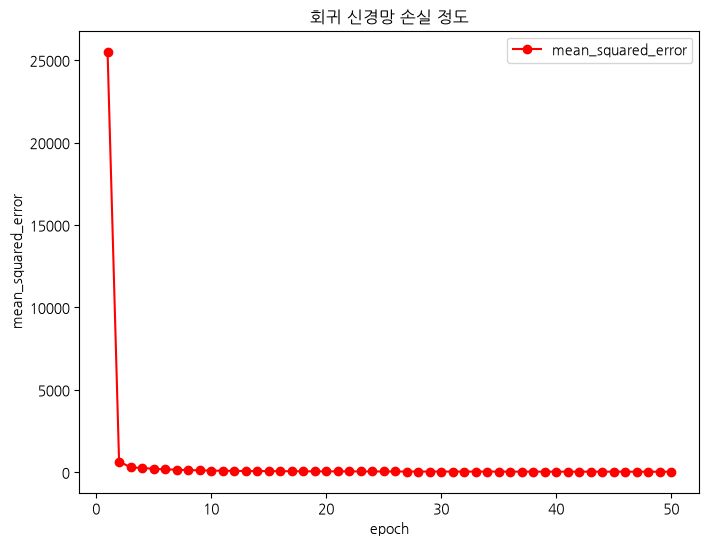

In [11]:
plt.figure(figsize=(8, 6))
plt.plot(epoch, loss, 'ro-', label='mean_squared_error')
plt.title('회귀 신경망 손실 정도')
plt.xlabel('epoch')
plt.ylabel('mean_squared_error')
plt.legend()
plt.show()

실제값과 예측값 시각화

In [12]:
df = pd.DataFrame(y_test)
df.columns = ['real_value']
df

,real_value
329,22.6
371,50.0
219,23.0
403,8.3
78,21.2
...,...
49,19.4
498,21.2
309,20.3
124,18.8


In [13]:
# predict() 메소드에 테스트 데이터를 넘겨서 에측값을 계산한다.
predict = model.predict(x_test)
print(type(predict), predict.shape)
predict

4/4 [==============================] - 0s 3ms/step
<class 'numpy.ndarray'> (127, 1)


array([[19.621265 ],
       [22.261845 ],
       [24.513456 ],
       [14.369934 ],
       [19.325638 ],
       [22.328848 ],
       [20.245    ],
       [27.316666 ],
       [15.413075 ],
       [ 8.925082 ],
       [ 6.6260757],
       [11.2264   ],
       [14.467878 ],
       [ 8.456774 ],
       [30.106588 ],
       [26.392124 ],
       [21.766478 ],
       [29.761684 ],
       [22.766155 ],
       [21.248615 ],
       [23.244696 ],
       [19.23618  ],
       [19.504543 ],
       [25.846727 ],
       [21.403252 ],
       [12.840118 ],
       [20.10012  ],
       [12.335485 ],
       [28.128286 ],
       [18.185947 ],
       [16.856365 ],
       [19.817078 ],
       [23.144554 ],
       [21.969412 ],
       [22.86804  ],
       [18.980162 ],
       [ 9.990427 ],
       [22.195427 ],
       [12.223661 ],
       [ 9.308468 ],
       [20.553316 ],
       [18.576277 ],
       [18.783312 ],
       [15.305592 ],
       [21.407476 ],
       [27.15881  ],
       [17.407864 ],
       [16.84

In [14]:
df['predict_value'] = predict
df

,real_value,predict_value
329,22.6,19.621265
371,50.0,22.261845
219,23.0,24.513456
403,8.3,14.369934
78,21.2,19.325638
...,...,...
49,19.4,20.681438
498,21.2,19.698309
309,20.3,22.192104
124,18.8,24.771477


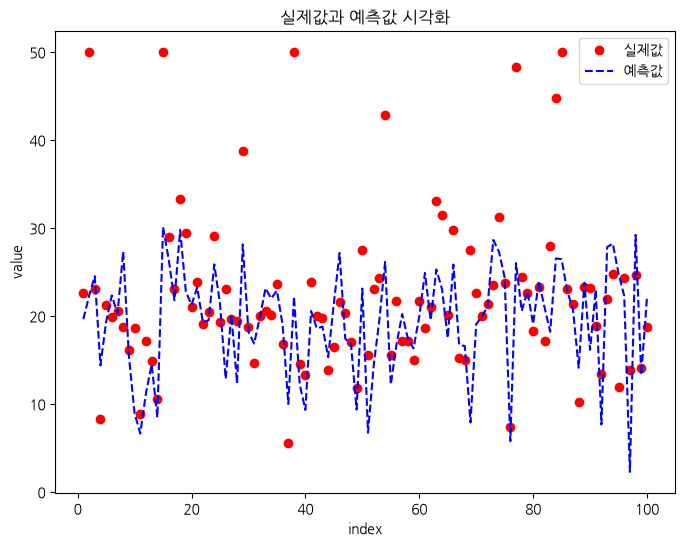

In [22]:
index = np.arange(1, len(df) + 1)[:100]
plt.figure(figsize=(8, 6))
plt.plot(index, df.real_value[:100], 'ro', label='실제값')
plt.plot(index, df.predict_value[:100], 'b--', label='예측값')
plt.title('실제값과 예측값 시각화')
plt.xlabel('index')
plt.ylabel('value')
plt.legend()
plt.show()

In [16]:
# 예측값을 기준으로 데이터프레임을 오름차순으로 정렬한다.
df_sort = df.sort_values(['predict_value'], ascending=True)
df_sort

,real_value,predict_value
438,8.4,0.836235
374,13.8,2.260418
417,10.4,2.862465
387,7.4,5.756113
418,8.8,6.626076
...,...,...
56,24.7,29.208225
196,33.3,29.761684
162,50.0,30.106588
306,33.4,35.612488


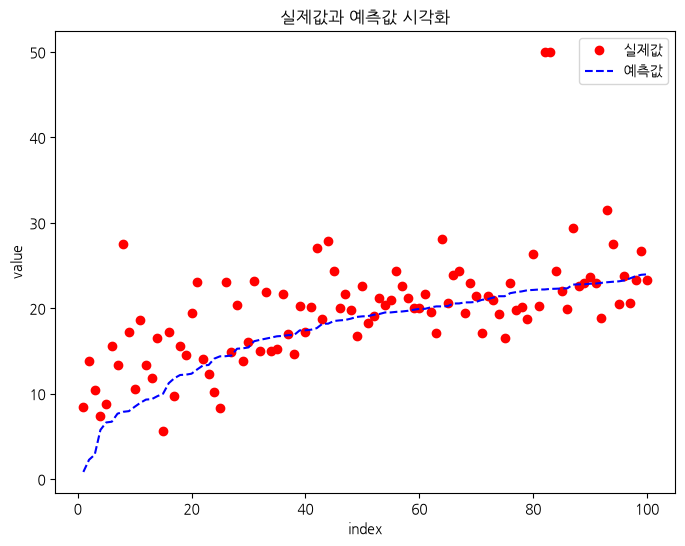

In [23]:
index = np.arange(1, len(df) + 1)[:100]
plt.figure(figsize=(8, 6))
plt.plot(index, df_sort.real_value[:100], 'ro', label='실제값')
plt.plot(index, df_sort.predict_value[:100], 'b--', label='예측값')
plt.title('실제값과 예측값 시각화')
plt.xlabel('index')
plt.ylabel('value')
plt.legend()
plt.show()